# SpinNetworkCalculator — Introductory Tutorial

Welcome! This notebook walks you through the full workflow of SpinNetworkCalculator step by step.

---

## What is a spin network?

A **spin network** is a special kind of graph (a collection of nodes connected by edges) where:
- Every node is connected to **exactly 3 edges** — called a *trivalent* graph
- Every edge carries a **spin value**: a non-negative multiple of ½ — that is, 0, ½, 1, 3/2, 2, ...
- The three edge values meeting at any node must satisfy the **triangular inequality**: |j₁ − j₂| ≤ j₃ ≤ j₁ + j₂

The **norm** of a spin network is a single number computed from all the edge labels using angular momentum recoupling theory (Wigner 6j symbols).

This library takes a spin network as input, performs a symbolic algebraic reduction, and returns the norm as a floating-point number.  It also tracks **evolutionary transitions** between network states and computes transition probabilities.

---

## Contents

| Part | What you will do |
|------|------------------|
| 0 | Set up the environment |
| 1 | Draw or load a spin network |
| 2 | Inspect the graph structure |
| 3 | Assign spin values to symbolic edge labels |
| 4 | Compute the symbolic norm |
| 5 | Evaluate numerically |
| 6 | Save and reload results |
| 7 | Scan many spin values at once |
| 8 | Performance, backends, and how results are validated |
| **9** | **Evolutionary transitions and probabilities** |
| — | Tips and common mistakes |

## How to use this notebook

A Jupyter notebook is made of **cells**. There are two types:
- **Text cells** (white background, like this one) — explanations and instructions
- **Code cells** (grey background) — Python instructions you can run

**To run a single code cell:**
1. Click on the cell to select it
2. Press **Shift + Enter** — this runs the cell and moves to the next one
   *(alternatively, press **Ctrl + Enter** to run and stay on the same cell)*

**To run everything from scratch:**
- Menu bar → **Kernel** → **Restart & Run All**

> ⚠️ **Always run cells in order, from top to bottom.**
> Each cell can use variables defined in the cells above it.
> If you see a `NameError` or `ImportError`, restart the kernel and run from the top.

---
## Part 0 — Set up the environment

Run the two cells below once at the beginning of every session.

**Cell 0a** checks that the library is importable and that you launched Jupyter from the right folder.

**Cell 0b** enables the graphical interface (needed for drawing, inspecting, and editing graphs).

In [2]:
# Cell 0a: Import check
# If this prints a green tick, you are ready. If it prints a cross, read the
# error message — the most common cause is launching Jupyter from the wrong folder.

import sys, os

# Add the project root to Python's search path so 'from src.api import ...' works.
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

try:
    from src.api import (
        new_network, load_network, SpinArg, Formula,
        # Phase 2: evolutionary genealogy
        Transition, LineageError, calculate_probability, TreeVisualizer,
    )
    print("✓  SpinNetworkCalculator imported successfully")
    print(f"   Python {sys.version.split()[0]}  |  Working directory: {project_root}")
except ImportError as e:
    print(f"✗  Import failed: {e}")
    print()
    print("   Fix: launch Jupyter from the SpinNetworkCalculator project folder:")
    print("   $ cd /path/to/SpinNetworkCalculator")
    print("   $ jupyter notebook")

✓  SpinNetworkCalculator imported successfully
   Python 3.11.2  |  Working directory: /Users/natteco/Desktop/Doctorat/travail/code/SpinNetworkCalculator


In [3]:
# Cell 0b: Enable the GUI in Jupyter
# This tells Jupyter to share its event loop with Tkinter (the GUI toolkit).
# Without it, windows opened by new_network() / display() / modify() will freeze.
# This cell has no visible output — that is normal.

%gui tk
print("✓  Tkinter GUI mode enabled")

✓  Tkinter GUI mode enabled


---
## Part 1 — Draw or load a spin network

You have two options. **Choose one** and run that cell; skip the other.

---

### Option A: Draw a new network interactively

Running **Cell 1a** opens a drawing window. Use these keyboard shortcuts inside the window:

| Key | Action |
|-----|--------|
| **N** | Add a node |
| **E** | Add an edge (click two nodes; type the spin value when prompted) |
| **M** | Move a node |
| **D** | Delete a node |
| **X** | Delete an edge |
| **Z** | Undo |
| **S** | Save and exit |

> **Suggested first graph:** Draw 2 nodes and connect them with **3 edges** (a *theta graph*).  
> Use spin values `0.5`, `0.5`, and `1` for the three edges.  
> When finished, press **S** to save.

> ⚠️ Do **not** close the window with the X button — that discards your graph.  
> Always press **S** to save and return.

In [30]:
# Cell 1a: Draw a new spin network interactively
# The drawing window will open. Press S when done.
# This cell blocks until you close the window.

snet = new_network()
print(f"\nGraph captured: {snet}")

✓ Node 1 added at (439, 448)
✓ Node 2 added at (434, 346)
✓ Node 3 added at (330, 257)
✓ Node 4 added at (506, 251)
✓ Node 5 added at (303, 122)
✓ Node 6 added at (504, 124)
✓ Edge added: 1 -- a -- 2
✓ Edge added: 2 -- b -- 3
✓ Edge added: 2 -- c -- 4
✓ Edge added: 4 -- d -- 3
✓ Edge added: 3 -- e -- 5
✓ Edge added: 4 -- f -- 6
✓ Graph saved successfully

Graph captured: SpinNetwork(id=13de2993, nodes=6, edges=6, depth=0)


### Option B: Load an existing file

Run **Cell 1b** instead if you already have a `.graphml` file.  
A sample file `drawn_graph.graphml` is included in the project — you can use it to follow along.

In [4]:
# Cell 1b: Load an existing .graphml file  (run this INSTEAD of Cell 1a)
# Change the filename if you want to load a different file.

snet = load_network("my_network.graphml")
print(f"Graph loaded: {snet}")

Graph loaded: SpinNetwork(id=2ab4a5fa, nodes=10, edges=10, depth=0)


---
## Part 2 — Inspect the graph structure

Before computing anything, let's see what we have.

- `print(snet)` shows a one-line summary: number of nodes, edges, free variables, and whether a formula is already cached.
- `snet.get_args()` returns the list of **free (symbolic) spin variables** — edge labels that are a name (like `j_1`) rather than a number (like `1.5`). If all edges are numeric, this list is empty.
- `snet.display()` opens a **read-only visual inspector** — a window showing the graph. Close it when done; the graph is not modified.

In [31]:
# Print a one-line summary of the graph
print(snet)

SpinNetwork(id=13de2993, nodes=6, edges=6, depth=0)


In [32]:
# List the symbolic (free) spin variables, if any
args = snet.get_args()

if args:
    print(f"\nThis graph has {len(args)} symbolic (free) spin variable(s):")
    for a in args:
        print(f"  Label: {a.label!r:10s}  Value: {a.value}  (is_numeric={a.is_numeric})")
else:
    print("\nAll edge labels are numeric — no free variables to assign.")


This graph has 6 symbolic (free) spin variable(s):
  Label: 'a'         Value: a  (is_numeric=False)
  Label: 'b'         Value: b  (is_numeric=False)
  Label: 'c'         Value: c  (is_numeric=False)
  Label: 'd'         Value: d  (is_numeric=False)
  Label: 'e'         Value: e  (is_numeric=False)
  Label: 'f'         Value: f  (is_numeric=False)


In [33]:
# Open the read-only visual inspector  (optional)
# A window showing the graph will appear. Close it when done.

snet.display()


LOADED: /var/folders/76/jhtq5rns20sftybk1f0z4qjw0000gn/T/tmpior_rhso.graphml
Nodes: 6
Edges: 6



---
## Part 3 — Compute the symbolic norm

`snet.evaluate_symbolic()` runs the full algebraic reduction pipeline:

1. **Glues the open edges** of the network together to form a closed graph
2. **Applies F-moves and triangle reductions** — a series of local graph transformations
3. **Expands 6j symbols** into canonical Wigner 6j form with theta/delta prefactors
4. **Canonicalises** the result by applying Regge symmetries and sorting

The output is a `Formula` object that holds the canonical symbolic expression.

**This is the most expensive step.** For a small network it takes a few seconds.  
For larger networks with many symbolic sum variables it may take longer.

> **The result is cached.** If you call `evaluate_symbolic()` again on the same
> unchanged graph, it returns the stored formula instantly — no recomputation.

In [8]:
# Run the symbolic reduction pipeline
print("Running symbolic reduction (this may take a few seconds)...")

formula = snet.evaluate_symbolic()

print(f"\nDone!")
print(f"Formula: {formula}")
print()
print("Reading the summary line:")
print("  terms=N      the canonical expression is a sum of N terms")
print("  free=[...]   spin variables still waiting for a numeric value")
print("  assigned=[]  spin variables already assigned")

Running symbolic reduction (this may take a few seconds)...

Done!
Formula: Formula(from graph, terms=1, free=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'], assigned=[])

Reading the summary line:
  terms=N      the canonical expression is a sum of N terms
  free=[...]   spin variables still waiting for a numeric value
  assigned=[]  spin variables already assigned


---
## Part 4 — Assign spin values to symbolic edge labels

If your graph has **symbolic** edge labels (text names like `j_1`, `a`, `x` instead of numbers),
you must assign them concrete spin values before numerical evaluation can proceed.

A **spin value** must be a non-negative multiple of ½:  
&nbsp;&nbsp;&nbsp;0, 0.5, 1, 1.5, 2, 2.5, 3, ...

The library checks the **triangular inequality** automatically when you call `set_args()`. If the values you chose violate |j₁ − j₂| ≤ j₃ ≤ j₁ + j₂ at any node, you will get an error telling you which node failed — choose different values.

> **If all your edge labels are already numbers**, this cell does nothing — skip ahead to Part 4.

In [9]:
# Get the list of free (symbolic) spin variables
args = snet.get_args()

if not args:
    print("No symbolic variables — all edge labels are numeric. Nothing to assign.")
else:
    # Assign a numeric value to each free variable.
    # Edit the value on the right of the '=' to the spin you want.
    # Valid choices: 0, 0.5, 1, 1.5, 2, 2.5, 3, ...
    for a in args:
        a.value = 10.0    # ← change this value

In [10]:
# Show the new args list
print(f" New args:")
args

 New args:


[SpinArg(label='a', value=10.0, [numeric]),
 SpinArg(label='b', value=10.0, [numeric]),
 SpinArg(label='j', value=10.0, [numeric]),
 SpinArg(label='c', value=10.0, [numeric]),
 SpinArg(label='d', value=10.0, [numeric]),
 SpinArg(label='e', value=10.0, [numeric]),
 SpinArg(label='f', value=10.0, [numeric]),
 SpinArg(label='g', value=10.0, [numeric]),
 SpinArg(label='h', value=10.0, [numeric]),
 SpinArg(label='i', value=10.0, [numeric])]

In [ ]:
# Apply the assignments to the graph
# (This also validates the triangular inequality — you will see an error
#  if the chosen values are incompatible at some node.)
if args:
    snet.set_args(args)
    print("\n Assignments applied successfully.")
    print(f"Updated graph: {snet}")

In [ ]:
# We can also set all arguments to symbolic numbers
# for exmaple by doing:

for a in args:
    a.value = a.label

snet.set_args(args)

---
## Part 5 — Evaluate numerically

`formula.evaluate_numeric(args)` substitutes the assigned spin values into the symbolic expression and sums the result, returning a single Python `float`.

Under the hood it calls the **wigxjpf** C library to compute each Wigner 6j symbol numerically.

**Interpreting the result:**
- **Non-zero**: the spin network is physically allowed
- **Zero**: the spin configuration violates SU(2) angular momentum coupling rules
- **Very small (< 10⁻¹⁰)**: likely a genuine near-cancellation rather than a bug — the individual 6j symbols are validated to machine precision against an independent implementation (see Part 8)

**On signs.** The individual factors inside the formula (θ, Δ, the (−1)^… prefactors) each carry a sign, and those signs cancel against one another during the summation — so they are kept all the way through. The modulus is a property of the *norm*, not of the individual factors, so `abs()` is applied exactly once, at the very end, right before `evaluate_numeric()` hands the value back. If you evaluate a formula string yourself through `FormulaEvaluator`, you get the **signed** value:

```python
from src.spin_evaluator import FormulaEvaluator
fe = FormulaEvaluator(verbose=False)
fe.evaluate("theta(1,1,1)")   # -> -24.0, not +24.0
fe.cleanup()
```

**If the reduction cannot finish**, `evaluate_symbolic()` raises `ReductionError` rather than returning a partial answer. See the Tips section at the end.


In [11]:
# Evaluate the formula numerically
result = formula.evaluate_numeric(args)

print(f"Norm = {result}")

Using serial backend (pass backend='multiprocessing' for very large summations)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed
Norm = 3.215007853264763e+64


In [9]:
# Evaluate directly feeding the arguments to the graph function
result = snet.evaluate_numeric(args)

print(f"Norm = {result}")

Using serial backend (pass backend='multiprocessing' for very large summations)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed
Norm = 3.215007853264763e+64


In [ ]:
# Evaluate the formula numerically (only works if no args)
result = formula.evaluate_numeric()

print(f"Norm = {result}")

---
## Part 6 — Save and reload results

You can save both the **graph** and the **formula** to disk:

| What | Method | File type | Can reload? |
|------|--------|-----------|-------------|
| Graph | `snet.save("name.graphml")` | GraphML | Yes, with `load_network()` |
| Formula (text) | `formula.save("name.txt", "txt")` | Plain text | Yes, with `Formula.load()` |
| Formula (PDF) | `formula.save("name.pdf", "pdf")` | LaTeX PDF | Visual only |

A formula loaded from `.txt` supports `evaluate_numeric()` just like one computed from scratch — without having to rerun the expensive symbolic reduction.

In [16]:
# Save the graph (can be reloaded later with load_network)
snet.save("my_network.graphml")
print("✓  Graph saved to my_network.graphml")

# Save the formula as a plain-text Python expression (fast to reload)
formula.save("my_norm.txt", "txt")
print("✓  Formula saved to my_norm.txt")

# Save the formula as a LaTeX-rendered PDF
formula.save("my_norm.pdf", "pdf")
print("✓  Formula saved to my_norm.pdf")

✓  Graph saved to my_network.graphml
Saved formula to my_norm.txt
✓  Formula saved to my_norm.txt
Saved LaTeX expression to my_norm.pdf
✓  Formula saved to my_norm.pdf


In [ ]:
# Reload the formula from the text file and re-evaluate
# No symbolic reduction needed — the expression is already stored in the file.

f2 = Formula.load("my_norm.txt")
print(f"Loaded: {f2}")

result2 = f2.evaluate_numeric(args)
print(f"Result (reloaded): {result2}")

# Verify it matches
print(f"Matches original:  {abs(result - result2) < 1e-10}")

---
## Part 7 — Scan a range of spin values

If a network has a symbolic edge label (e.g. `j_1`), you may want to compute the norm for **many values** of that spin — for example, to plot how the norm varies.

`formula.evaluate_batch()` does this efficiently:
- It initialises the underlying C++ wigxjpf tables **once** and reuses them for every spin value
- This is much faster than calling `evaluate_numeric()` in a Python loop

> **This section requires at least one free (symbolic) variable.**  
> If all variables were assigned in Part 3, go back to Part 3 and leave one symbolic
> (delete the `a.value = ...` line for that variable and re-run from there).
> Alternatively, reload from the saved file and skip the assignment step.

The cell below automatically detects which variables are free and scans the first one.

In [12]:
rng = snet.get_edge_range('a')

In [13]:
print(rng)

None


In [14]:
# Scan the first free variable over its triangle-allowed half-integer values.
#
# Each batch entry must supply a value for EVERY free variable, not just the
# one being scanned (evaluate_batch treats each entry independently) — so we
# take one full get_args() snapshot per value, give every OTHER free
# variable a fixed baseline, and vary only the scanned one.
#
# The values tried for the scanned edge are restricted to what the
# triangular inequality allows at the vertices it touches in `snet` (using
# the OTHER two edges at each vertex — see Graph.get_edge_range()).

from src.utils import spin_values_in_range

base_args = formula.get_args()
free_args = [a for a in base_args if not a.is_numeric]

if not free_args:
    print("No free variables — all are already assigned.")
    print("To run this section, reload the formula and leave one variable unassigned:")
    print("  f3 = Formula.load('my_norm.txt')")
    print("  results = f3.evaluate_batch([[SpinArg('j_1', v)] for v in spin_values])")
else:
    scanned_label = free_args[0].label
    print(f"Scanning variable: '{scanned_label}'")

    rng = snet.get_edge_range(scanned_label)
    if rng is not None:
        spin_values = spin_values_in_range(*rng)
        print(f"Triangle-allowed range: [{rng[0]}, {rng[1]}]  →  {spin_values}")
    else:
        # No vertex touching this edge had both other edges numeric yet
        # (e.g. every neighbour is also symbolic) — fall back to a default.
        spin_values = [n * 0.5 for n in range(1, 9)]   # 0.5 → 4.0
        print("Couldn't derive a triangle-allowed range (neighbouring edges "
              f"still symbolic) — using default {spin_values}")

    # One full snapshot per spin value: every free variable other than the
    # scanned one gets a fixed baseline (1.0) so each batch entry is complete.
    args_list = [
        [SpinArg(a.label, v if a.label == scanned_label else 1.0) for a in free_args]
        for v in spin_values
    ]

    # Run the batch — one evaluator shared across all spin values (efficient)
    results = formula.evaluate_batch(args_list)

    print(f"\n  {'j':>6}   {'Norm':>20}")
    print("  " + "-" * 30)
    for v, r in zip(spin_values, results):
        print(f"  {v:>6.1f}   {r:>20.8f}")

Scanning variable: 'a'
Couldn't derive a triangle-allowed range (neighbouring edges still symbolic) — using default [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
Using serial backend (pass backend='multiprocessing' for very large summations)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed

       j                   Norm
  ------------------------------
     0.5             0.00000000
     1.0         30720.00000000
     1.5             0.00000000
     2.0         38400.00000000
     2.5             0.00000000
     3.0             0.00000000
     3.5             0.00000000
     4.0             0.00000000


---
## Part 8 — Performance, backends, and how results are validated

### Short version: leave the default alone

`backend="auto"` resolves to **serial**, and for almost every network that is the right choice. The numbers below are measured, not estimated — reproduce them with `python scripts/benchmark_backends.py`.

### Why there is no GPU option

The dominant cost of every evaluation is the Wigner 6j symbol, computed by **wigxjpf**, a C library. Array frameworks cannot trace, `jit` or `vmap` into a C library, so there is no GPU code path for the quantity that actually matters. JAX support was removed for this reason.

### Why CPU parallelism rarely helps

Each worker process must be spawned *and* must re-allocate its own wigxjpf tables:

| Quantity | Measured (8-core arm64 macOS, `max_two_j=200`) |
|---|---|
| Pool startup + wigxjpf init, 7 workers | ~0.8–1.0 s |
| Serial cost per summation term | ~2.6 µs |
| **Break-even** | **~350,000 summation terms** |
| Speedup at 2.7 M terms | 2.55× |

Below the break-even, parallelism is *slower* — by up to three orders of magnitude. It only pays off for very large multi-variable summations, where the term count is the product of several F-variable ranges.

| Backend | What it does |
|---|---|
| `"auto"` | Serial (the default) |
| `"serial"` | Single thread |
| `"multiprocessing"` | Splits the outermost summation across cores. Times a pilot slice first and stays serial unless the work clearly exceeds the ~1 s startup cost |

### Multiprocessing is disabled inside Jupyter — on purpose

On macOS and Windows Python's `spawn` start method **re-imports `__main__` in every worker**. A notebook has no importable `__main__`, so the workers fail and the pool retries forever — the classic "multiprocessing hangs in Jupyter". No `try/except` can catch it, because the child hangs rather than raising.

The library detects this and falls back to serial instead of hanging. To actually use multiple cores, run from a **script file** with a guarded entry point:

```python
if __name__ == "__main__":
    main()
```

### How you know the numbers are right

`tests/test_validation.py` (run it with `pytest tests/test_validation.py -v`) checks the numerical core against sources independent of this codebase:

- every Wigner 6j symbol against **`sympy.physics.wigner`**, exhaustively, for all integer and half-integer arguments up to 2j = 3 — zero mismatches
- θ and Δ against factorial closed forms re-derived from scratch
- 6j **orthogonality**, evaluated through the `Sum()` machinery so the summation bounds are on trial too
- ‖closed θ net‖ = Θ(1,1,2)² = 900, and ‖tetrahedron‖ = θ(1,1,1)⁴ · W6j² = 9216
- the tetrahedron norm is identical under **all 24 relabelings of its vertices** (a norm cannot depend on what you call the nodes — this is a regression test for a bug that made 6 of the 24 return 1.0 instead of 9216)
- serial and parallel results are **bitwise identical**
- **the transition sum rule**: summed over every admissible reconnection channel *c*, the probabilities come to exactly **1**. This is the strongest single check — it exercises the norms, the Δ(c)/Θ(c,s,t) factor and the direction of the ratio at once

You can also raise `max_two_j` for larger spins (default 200, supporting j up to 100).


In [15]:
# What will actually run on this machine, in this context?
from src.spin_evaluator import SpinNetworkEvaluator, _multiprocessing_is_usable

resolved = SpinNetworkEvaluator(max_two_j=2, backend="auto", verbose=False)
print(f"backend='auto' resolves to : {resolved.backend!r}")
resolved.cleanup()

print(f"multiprocessing usable here: {_multiprocessing_is_usable()}")
print()
print("In a notebook, multiprocessing is expected to be False: the 'spawn'")
print("start method cannot re-import __main__ from a kernel. Run a script")
print("file with an `if __name__ == \"__main__\":` guard to use many cores.")


backend='auto' resolves to : 'serial'
multiprocessing usable here: False

In a notebook, multiprocessing is expected to be False: the 'spawn'
start method cannot re-import __main__ from a kernel. Run a script
file with an `if __name__ == "__main__":` guard to use many cores.


In [16]:
# Backends must agree exactly — the value must not depend on how it was computed.
# In a notebook "multiprocessing" transparently falls back to serial (see above),
# so this is a cheap consistency check here rather than a performance test.

r_serial = formula.evaluate_numeric(args, backend="serial")
print(f"serial          : {r_serial}")

r_parallel = formula.evaluate_numeric(args, backend="multiprocessing")
print(f"multiprocessing : {r_parallel}")

if r_serial == r_parallel:
    print("\n✓  Bitwise identical")
else:
    print(f"\n⚠  Backends differ by {abs(r_serial - r_parallel)!r} — please report this")

# For a real parallel-vs-serial timing comparison, run from a terminal:
#     python scripts/check_backends.py       # verifies serial == parallel
#     python scripts/benchmark_backends.py   # measures the break-even point


Using serial backend (single-threaded)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed
serial          : 3.215007853264763e+64
🚀 Using multiprocessing backend
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed
multiprocessing : 3.215007853264763e+64

✓  Bitwise identical


In [ ]:
# Example: large spins — raise max_two_j as needed
# The default max_two_j=200 supports spin values j up to 100.
# To support j up to 500, use max_two_j=1000.

# result_large = formula.evaluate_numeric(max_two_j=1000)
# print(f"Result (large j tables): {result_large}")

---
## Part 9 — Evolutionary transitions and probabilities

To a spin network, one can apply operations and recouplings, i.e. insertions and fusion of (open) ends: the network is said to **transition** to another one.  From each such transition, the parent network gains a child, and the two are linked in a genealogy tree.

### Key concepts

| Concept | What it means |
|---------|---------------|
| **Transition** | The structural change between a parent and a child SpinNetwork |
| **added_graph** | The new edges attached to the parent during the transition |
| **produced_open_ends** | New open ends created by the reconnection |
| **Genealogy tree** | The directed tree of all parent–child relationships |
| **Probability** | The number the proto-probability gives for a specified recoupling outcome given the norms of the graphs involved |

### The probability formula

$$\operatorname{Prob}(\cap_{e\in E_{\text{new}}}e\,\Big\vert\,l_1\,\vert\,\ldots\,\vert\,l_n) = \prod_{e \in E_{\text{new}}} |f_e|\cdot\prod_{l \in E_{\text{old}}}\frac{|\Delta_l|}{\|G_\Delta^l\|}\cdot\frac{\|G_{\text{out}}\|}{\|G_{\text{in}}\|}$$

- $\|G_{\text{in}}\|$, $\|G_{\text{out}}\|$ — norms of the parent and child networks  
- $\|G_\Delta^l\|$ — norm of the added-edges subgraph on edge $l$ (= 1 when only reconnecting existing open ends)  
- $\prod |f_e|$ — product of $\Delta(e)$ symbols for each newly produced open edge, divided by $\Theta(e,e_1,e_2)$ at each reconnection vertex
- $\prod |\Delta_l|$ - product of $\Delta(l)$ symbols for each old open edge where an insertion was made.

> **`calculate_probability()` returns a `Formula`, not a number** — exactly like `evaluate_symbolic()`. This is what lets a symbolic edge (e.g. `j_1`) stay alive across a transition, so you can later scan many assignments with `evaluate_batch()` without redoing the expensive graph reduction. There is no cheap cached probability: the Transition Tool only records structural metadata, so the norms are always computed from the Formula.

### Jupyter display

Any `SpinNetwork` cell automatically renders its graph as an embedded image.  
The `TreeVisualizer` shows the full genealogy as a 2-D diagram.

### Part 9a — Creating a transition

`snet.transition_to()` opens the **Transition Tool** GUI loaded with the current graph.
Inside that window you can:

| Action | How |
|--------|-----|
| Add a new edge | Press **E**, click two nodes, type the spin label |
| Mark a reconnection | Select two open nodes, press **C**; choose a spin value `c` |
| Compute and close | Press **S** — this evaluates all norms and probabilities |

> ⚠️ Always press **S** to compute before closing the window.  
> Closing with the X button discards the session and raises a `RuntimeError`.

The method returns a new `SpinNetwork` — the child state.  
The parent (`n1`) and child (`n2`) are automatically linked; the `Transition` object between them is stored as `n2.parent_transition`.

Parent network: SpinNetwork(id=13de2993, nodes=6, edges=6, depth=0)


SpinNetwork(id=13de2993, nodes=6, edges=6, depth=0)
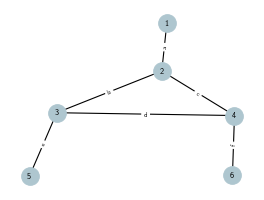

In [34]:
# Cell 9a-1: Load (or reuse) the parent network
# We use the file saved in Part 6; swap in your own .graphml if you prefer.

n1 = snet 
#n1 = load_network("my_network.graphml") # Uncomment this line to load a saved network
print(f"Parent network: {n1}")

# Displaying n1 in a Jupyter cell renders the graph inline:
n1

In [35]:
# Cell 9a-2: Open the Transition Tool and perform a reconnection
# The GUI will open. Select two open-ended nodes, press C to reconnect,
# then press S to compute. The window closes automatically after S.

n2 = n1.transition_to()

print(f"Child network:  {n2}")
print()

# Inspect the Transition that links n1 → n2
# (Transition has no cheap cached probability — see Part 9b for that.)
t = n2.parent_transition
print(f"Transition:         {t}")
print(f"New open ends:      {t.produced_open_ends}")
print(f"n1 is t.parent:     {n1 is t.parent}")
print(f"n2 is t.child:      {n2 is t.child}")

✓ Loaded graph from /var/folders/76/jhtq5rns20sftybk1f0z4qjw0000gn/T/tmp9frerno1/input.graphml
  Nodes: 6, Edges: 6
✓ Added node 7 at (13, 408)
✓ Added node 8 at (72, 342)
✓ Added edge: 8 --[0.5]-- 6 (flagged)
✓ Added edge: 6 --[f - 0.5]-- 7 (flagged)

✓ Reconnected: 0.5 + e → o
✓ Saved modified graph to /var/folders/76/jhtq5rns20sftybk1f0z4qjw0000gn/T/tmp9frerno1/transition_to_graph.graphml
Child network:  SpinNetwork(id=ba575b82, nodes=8, edges=9, depth=1)

Transition:         Transition(parent=13de2993, child=ba575b82, +2 open ends)
New open ends:      frozenset({'9', '7'})
n1 is t.parent:     True
n2 is t.child:      True


In [19]:
# The child renders inline too:
n2.display()


LOADED: /var/folders/76/jhtq5rns20sftybk1f0z4qjw0000gn/T/tmp98k2ys7g.graphml
Nodes: 12
Edges: 13



### Part 9b — Computing the transition probability

`calculate_probability(network_in, network_out)` is the main probability function.  It mirrors `Graph.evaluate_symbolic()`: it returns a symbolic **`Formula`**, not a number — building it is the expensive step (it reduces `G_in`, `G_out`, and the added-edges subgraph).

| Call | Behaviour |
|------|-----------|
| `formula = calculate_probability(n1, n2)` | Builds the symbolic probability formula (like `evaluate_symbolic()`) |
| `formula.evaluate_numeric()` | Numeric value, using whatever spin values are already assigned |
| `formula.evaluate_numeric(args)` | Numeric value with custom spin values |
| `formula.evaluate_batch(args_list)` | Scans many spin assignments efficiently (one shared evaluator) |

The function traces the path from `n1` to `n2` in the genealogy tree automatically.
If `n2` is not a descendant of `n1`, it raises `LineageError`.

### What goes into P

    P = norm(G_out) x (Delta/Theta factor)  /  (norm(G_in) x norm(G_Delta))

- each **reconnection** (c, s, t) contributes Δ(c)/Θ(c, s, t)
- each parent **open end consumed outside a reconnection** contributes Δ(j) —
  for example a dangling leg that you build out into a vertex. Open ends that
  took part in a reconnection are already covered by its triplet and are not
  counted twice
- `G_Delta` is the subgraph of edges you explicitly added; its norm divides the result
- a forbidden reconnection (triangle inequality violated) gives exactly 0 rather than an error

Summed over every admissible channel `c`, these probabilities come to **1**.

If you need a transition without the GUI, `n1.transition_from_metadata(child_graph, metadata)`
performs exactly the parsing `transition_to()` does after the window closes.


In [57]:
# Cell 9b-1: Build the symbolic probability formula 
formula_p = calculate_probability(n1, n2)      # like evaluate_symbolic(): expensive, builds the Formula

In [ ]:
# and evaluate it
p = formula_p.evaluate_numeric()               # numeric value (works directly if all labels are numeric)
print(f"P(n1 → n2) = {p:.8f}")

In [107]:
# Cell 9b-2: Probability with custom spin values
# formula_p.get_args() lists the free variables across G_in, G_out, and G_delta combined.
import copy


args_1 = n2.get_args()
args_2 = copy.deepcopy(args_1)
args = copy.deepcopy(args_1)

In [111]:
# Assign concrete values — edit these to the spins you want to probe
for a in args_2:
    if a.label == 'o':
        a.value = 10.5
    elif a.label == 'f - 0.5':
        a.value = 9.5
    else:
        a.value = 10
for a in args_1:
    if a.label == 'o':
        a.value = 9.5
    elif a.label == 'f - 0.5':
        a.value = 9.5
    else:
        a.value = 10
for a in args:
    if a.label == 'f - 0.5':
        a.value = 9.5
    elif a.label !='o':
        a.value = 10

In [112]:
args_1

[SpinArg(label='a', value=10, [numeric]),
 SpinArg(label='b', value=10, [numeric]),
 SpinArg(label='c', value=10, [numeric]),
 SpinArg(label='d', value=10, [numeric]),
 SpinArg(label='e', value=10, [numeric]),
 SpinArg(label='f', value=10, [numeric]),
 SpinArg(label='f - 0.5', value=9.5, [numeric]),
 SpinArg(label='o', value=9.5, [numeric])]

In [113]:
args_2

[SpinArg(label='a', value=10, [numeric]),
 SpinArg(label='b', value=10, [numeric]),
 SpinArg(label='c', value=10, [numeric]),
 SpinArg(label='d', value=10, [numeric]),
 SpinArg(label='e', value=10, [numeric]),
 SpinArg(label='f', value=10, [numeric]),
 SpinArg(label='f - 0.5', value=9.5, [numeric]),
 SpinArg(label='o', value=10.5, [numeric])]

In [114]:
args

[SpinArg(label='a', value=10, [numeric]),
 SpinArg(label='b', value=10, [numeric]),
 SpinArg(label='c', value=10, [numeric]),
 SpinArg(label='d', value=10, [numeric]),
 SpinArg(label='e', value=10, [numeric]),
 SpinArg(label='f', value=10, [numeric]),
 SpinArg(label='f - 0.5', value=9.5, [numeric]),
 SpinArg(label='o', value=o, [symbolic])]

In [101]:
# Evaluate the formula with the args 
p_custom_1 = formula_p.evaluate_numeric(args_1)
print(f"\nP(n1 → n2) = {p_custom_1:.8f} for o=9.5")
p_custom_2 = formula_p.evaluate_numeric(args_2)
print(f"\nP(n1 → n2) = {p_custom_2:.8f} for o=10.5")
sum = p_custom_1+p_custom_2
print(f"\nSum={sum}")

Using serial backend (pass backend='multiprocessing' for very large summations)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed

P(n1 → n2) = 0.73809524 for o=9.5
Using serial backend (pass backend='multiprocessing' for very large summations)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed

P(n1 → n2) = 0.26190476 for o=10.5

Sum=1.0


In [115]:
# Cell 9b-3: Scan many spin assignments efficiently with evaluate_batch()
#
# Each batch entry must supply a value for EVERY free variable in formula_p,
# not just the one being scanned — a transition's Formula can carry many
# free variables at once (from G_in, G_out, and G_delta combined — this one
# has as many as `args` shows).  So each entry here is a full copy of the
# `args` list from Cell 9b-2 (already assigned except one variable),
# overriding only the value of the variable being scanned.
#
# The scanned label's range is restricted to what the triangular inequality
# allows at the vertices its edge touches — checked in BOTH n1 and n2 (the
# same label can carry over from parent to child) and intersected together.

from src.utils import spin_values_in_range

free_vars = [a.label for a in args if not a.is_numeric]

if not free_vars:
    print("No free variables left in `args` — nothing to scan.")
else:
    scanned_label = free_vars[0]

    ranges = [r for r in (n1.get_edge_range(scanned_label),
                          n2.get_edge_range(scanned_label)) if r is not None]

    if ranges:
        j_min = max(r[0] for r in ranges)
        j_max = min(r[1] for r in ranges)
        spin_values = spin_values_in_range(j_min, j_max)
        print(f"Scanning '{scanned_label}' over triangle-allowed range "
              f"[{j_min}, {j_max}]: {spin_values}")
    else:
        # No vertex touching this label had both other edges numeric yet
        # (e.g. every neighbour is also symbolic) — fall back to a default.
        spin_values = [n * 0.5 for n in range(9, 11)]   # 4.5 → 5.0
        print(f"Couldn't derive a triangle-allowed range for '{scanned_label}' "
              f"(neighbouring edges still symbolic) — using default {spin_values}")

    args_list = [
        [SpinArg(a.label, v if a.label == scanned_label else a.value) for a in args]
        for v in spin_values
    ]

    probs = formula_p.evaluate_batch(args_list)

    print(f"\n  {'j':>6}   {'P':>20}")
    print("  " + "-" * 30)
    for v, p_v in zip(spin_values, probs):
        print(f"  {v:>6.1f}   {p_v:>20.8f}")

Couldn't derive a triangle-allowed range for 'o' (neighbouring edges still symbolic) — using default [4.5, 5.0]
Using serial backend (pass backend='multiprocessing' for very large summations)
Initializing wigxjpf tables for max 2j = 200...
✓ Wigxjpf initialized and ready
✓ Wigxjpf memory freed

       j                      P
  ------------------------------
     4.5             0.00000000
     5.0             0.00000000


In [ ]:
# Cell 9b-4: LineageError — what happens when n2 is not a descendant of n1
# Run this cell to see the guard in action.

from src.api import load_network, LineageError

n_other = load_network("my_network.graphml")   # a fresh, unrelated network

try:
    calculate_probability(n2, n_other)         # n_other is NOT descended from n2
except LineageError as e:
    print(f"LineageError caught (expected): {e}")

### Part 9c — Inspecting the genealogy tree

Two tools are available for exploring the genealogy:

| Tool | Output |
|------|--------|
| `TreeVisualizer.display_tree(root)` | 2-D matplotlib plot of the full ancestry |
| `TreeVisualizer.ascii_tree(root)` | Plain-text tree for quick console inspection |

Both start from the given node and follow all children recursively.
You can call them on any node in the tree, not just the root.

In [ ]:
# Cell 9c-1: ASCII tree — quick text summary of the genealogy
print(TreeVisualizer.ascii_tree(n1))

In [ ]:
# Cell 9c-2: 2-D genealogy plot
# Each node shows the SpinNetwork id and its graph size.
# Each edge shows how many open ends the transition produced
# (there is no cheap cached probability to display — see Part 9b).

TreeVisualizer.display_tree(n1)

### Part 9d — Multi-hop transitions and tree branching

A single parent can have **multiple children** (different reconnection channels).  
The genealogy then branches, and you can compute the probability for any path through the tree.

- Call `n1.transition_to()` multiple times to create several children of the same parent.
- Call `n2.transition_to()` to go one generation deeper.
- `calculate_probability(n1, n3)` automatically composes the two intermediate transitions.

> **Note:** For multi-hop paths the probability is recomputed from scratch — it is not simply the product of single-step probabilities, because the norms and Δ/Θ factors interact.

In [ ]:
# Cell 9d-1: Create a second child of n1 (different reconnection channel)
# Open the Transition Tool again — this time choose a different reconnection.

n2b = n1.transition_to()

print(f"n1 now has {len(n1.children)} child transition(s):")
for i, t in enumerate(n1.children):
    p_i = calculate_probability(n1, t.child)
    print(f"  [{i}] P = {p_i:.6f}  →  child id={t.child._id}")

In [ ]:
# Cell 9d-2: Go one generation deeper from n2
n3 = n2.transition_to()

print(f"Multi-hop path: n1 → n2 → n3")
print(f"  Depth of n3: {n3._genealogy_depth()}")
print()

# calculate_probability composes the two transitions automatically
formula_multihop = calculate_probability(n1, n3)
p_multihop = formula_multihop.evaluate_numeric()
print(f"P(n1 → n3)  = {p_multihop:.8f}  [multi-hop, composed]")
print()

# The updated tree
print(TreeVisualizer.ascii_tree(n1))

In [ ]:
# Cell 9d-3: Full 2-D plot of the branched genealogy
TreeVisualizer.display_tree(n1, figsize=(10, 6), title="Full SpinNetwork Genealogy")

---
## Tips and common mistakes

### `NameError: name 'snet' is not defined`
You ran a cell before the cell that defines `snet`.  
Fix: **Kernel → Restart & Run All** to run everything from the top.

---

### `RuntimeError: No graph was saved`
You closed the drawing window with the **X button** instead of pressing **S**.  
Fix: run the `new_network()` cell again, draw your graph, and press **S**.

---

### `RuntimeError: Transition not completed`
You closed the Transition Tool with the **X button** instead of pressing **S**.  
Fix: run `n1.transition_to()` again, make your reconnection, and press **S** to compute.

---

### `ValueError: The following spin variables are still unassigned: ['j_1']`
You called `evaluate_numeric()` before assigning a value to `j_1`.  
Fix: go back to Part 3, assign a value, call `snet.set_args(args)`, then redo Part 4–5.

---

### `ValueError: Assigning 3.0 to 'j_1' would violate the triangular inequality`
The value you chose is not compatible with the other edges at some node.  
Fix: try a smaller value, or check which values satisfy |j₁ − j₂| ≤ j₃ ≤ j₁ + j₂ at that node.

---

### `LineageError: No path from … to …`
You passed two SpinNetworks that are not in an ancestor–descendant relationship.  
Fix: make sure `network_out` was created by calling `transition_to()` on `network_in` (or on one of its descendants).

---

### `ReductionError: Reduction did not complete`
The reduction moves assume every internal node is **trivalent** (exactly 3 edges).
Your graph has a node of some other degree, or is non-planar in a way the
face-finding fallback cannot handle.
The message lists the leftover edges and the vertex degrees it found.

This is deliberately an error, not a number: the reducer used to return whatever
partial product it had accumulated, which looked like a plausible norm but was wrong.
Fix: check the node degrees with `snet.display()`, and make every internal node trivalent.

---

### The GUI window froze / is unresponsive
Re-run the `%gui tk` cell (Cell 0b) and try again.

---

### I need spin values larger than j = 100
The default `max_two_j=200` pre-allocates wigxjpf tables for j up to 100.  
Raise it proportionally:
```python
result = formula.evaluate_numeric(max_two_j=2000)   # supports j up to 1000
```

---

## What's next?

- **Transition probabilities (API)** — `snet.transition_to()` and `calculate_probability()` in `src/api.py`
- **Genealogy visualisation** — `TreeVisualizer` in `src/visualizer.py`
- **Graph comparison** — `scripts/README_COMPARISON.md`
- **Backends and measured performance** — `PARALLEL_ACCELERATION.md`
- **Validation against known results** — `tests/test_validation.py`
  (`pytest tests/test_validation.py -v`)
- **Full API reference** — docstrings in `src/api.py`  
  *(In Jupyter: `from src.api import Formula; help(Formula)` to read them inline)*